# Attempting to train a model capable of discerning plastic types using FTIR spectroscopy data

Data(x) is wavenmumber, Data(Y) is transmittance

https://www.sciencedirect.com/science/article/pii/S2352340924005791#:~:text=This%20work%20introduces%20two%20datasets%3A%20FTIR-Plastics-C4%20%28Fourier%20Transform,corresponding%20to%20the%20most%20used%20synthetic%20polymers%20worldwide

In [59]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve, validation_curve
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [51]:
df = pd.read_csv('/kaggle/input/ftir-plastic-c8/FTIR_PLASTIC_c8.csv')

# Drop irrelevant metadata columns, keep 'Polymer' for the target
irrelevant_cols = ['IDE', 'Technic', 'Technique', 'Sample', 'BR', 'RST']
for col in irrelevant_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# Extract labels to get NumPy array of target classifiers
y = df['Polymer'].values

# Extract feature columns (transmittance values)
# Remove the 'Polymer' column to isolate data columns
df_data = df.drop(columns='Polymer')

assert df_data.shape[1] % 2 == 0, "Expected an even number of Data columns (pairs of x and y)"


In [52]:
df_data

,Data(x),Data(Y),Data(x).1,Data(Y).1,Data(x).2,Data(Y).2,Data(x).3,Data(Y).3,Data(x).4,Data(Y).4,...,Data(x).1864,Data(Y).1864,Data(x).1865,Data(Y).1865,Data(x).1866,Data(Y).1866,Data(x).1867,Data(Y).1867,Data(x).1868,Data(Y).1868
0,399.1927,71.8845,401.1211,72.7970,403.0496,73.3489,404.9781,73.6554,406.9065,73.8192,...,3993.855,95.0697,3995.7834,95.0639,3997.7119,95.0581,3999.6404,95.0508,4001.5688,95.0415
1,399.1927,96.7876,401.1211,96.9246,403.0496,97.0224,404.9781,97.0559,406.9065,97.0248,...,3993.855,98.1241,3995.7834,98.1257,3997.7119,98.1270,3999.6404,98.1266,4001.5688,98.1246
2,399.1927,66.1325,401.1211,67.1290,403.0496,67.8174,404.9781,68.1897,406.9065,68.2962,...,3993.855,93.0200,3995.7834,93.0228,3997.7119,93.0316,3999.6404,93.0396,4001.5688,93.0402
3,399.1927,68.6363,401.1211,69.5071,403.0496,70.0667,404.9781,70.3812,406.9065,70.5178,...,3993.855,95.2411,3995.7834,95.2405,3997.7119,95.2448,3999.6404,95.2504,4001.5688,95.2520
4,399.1927,70.3734,401.1211,71.4349,403.0496,72.2610,404.9781,72.8707,406.9065,73.3083,...,3993.855,94.5011,3995.7834,94.5043,3997.7119,94.5146,3999.6404,94.5249,4001.5688,94.5280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,399.1927,83.2940,401.1211,83.8013,403.0496,84.4910,404.9781,85.2283,406.9065,85.8892,...,3993.855,112.1800,3995.7834,112.2200,3997.7119,112.2600,3999.6404,112.2880,4001.5688,112.2960
2996,399.1927,97.1478,401.1211,97.5876,403.0496,98.1872,404.9781,98.8193,406.9065,99.3741,...,3993.855,105.4440,3995.7834,105.4670,3997.7119,105.4890,3999.6404,105.5010,4001.5688,105.5040
2997,399.1927,83.9846,401.1211,84.7421,403.0496,85.5384,404.9781,86.2647,406.9065,86.8608,...,3993.855,111.6090,3995.7834,111.6480,3997.7119,111.6880,3999.6404,111.7170,4001.5688,111.7270
2998,399.1927,87.6121,401.1211,87.8554,403.0496,88.2208,404.9781,88.6468,406.9065,89.0821,...,3993.855,105.4530,3995.7834,105.4610,3997.7119,105.4700,3999.6404,105.4750,4001.5688,105.4770


In [53]:
# Data(x) & Data(Y) alternate columns so we only want every other column starting from the 1st column for X
X = df_data.iloc[:, 1::2].values

print(X)

assert X.ndim == 2, "Feature matrix X should be 2-dimensional"
assert y.ndim == 1, "Label vector y should be 1-dimensional"
assert X.shape[0] == y.shape[0], "Number of samples in X and y must match"

[[ 71.8845  72.797   73.3489 ...  95.0581  95.0508  95.0415]
 [ 96.7876  96.9246  97.0224 ...  98.127   98.1266  98.1246]
 [ 66.1325  67.129   67.8174 ...  93.0316  93.0396  93.0402]
 ...
 [ 83.9846  84.7421  85.5384 ... 111.688  111.717  111.727 ]
 [ 87.6121  87.8554  88.2208 ... 105.47   105.475  105.477 ]
 [ 98.052   98.5505  99.146  ... 103.1    103.11   103.11  ]]


# Baseline Correction

Various factors can introduce distortions, leading to a non-flat baseline. These factors include instrumental noise, atmospheric water vapor, and impurities in the sample or solvent. Thus, we conduct baseline correction.

The graphs below visualise the baseline flat regions and the regions with peaks of actual absorption.

https://www.peakspectroscopy.com/baselineCorrection.html

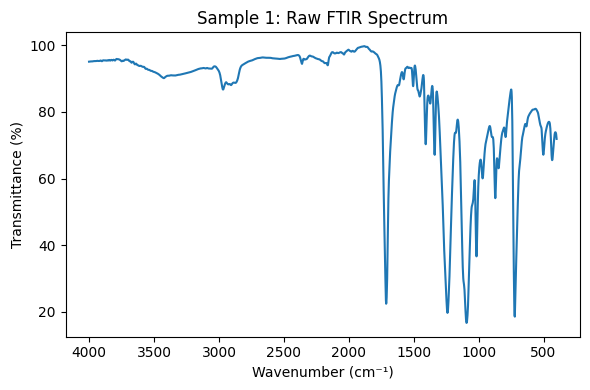

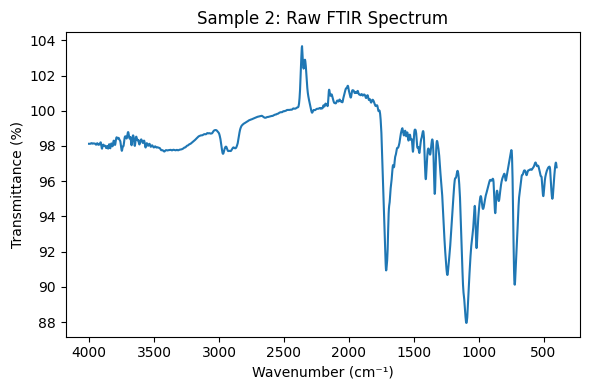

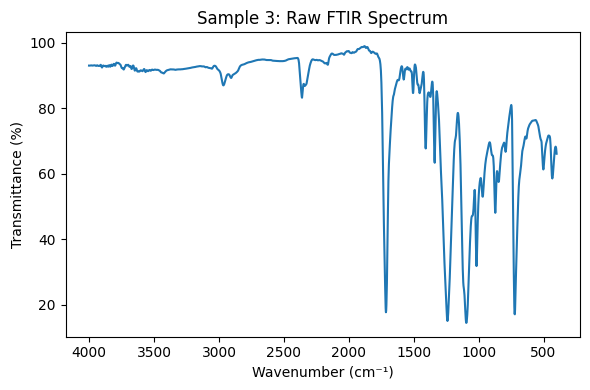

In [54]:
# Identify spectral columns
data_cols = [col for col in df.columns if col.startswith('Data')]
x_cols = data_cols[::2]  # wavenumber columns
y_cols = data_cols[1::2] # absorbance columns

# Plot raw spectra for the first 3 samples to visualize baseline drift
for i in range(3):
    x = df.loc[i, x_cols].values
    y = df.loc[i, y_cols].values
    
    plt.figure(figsize=(6, 4))
    plt.plot(x, y)
    plt.gca().invert_xaxis()
    plt.title(f'Sample {i+1}: Raw FTIR Spectrum')
    plt.xlabel('Wavenumber (cm⁻¹)')
    plt.ylabel('Transmittance (%)')
    plt.tight_layout()
    plt.show()

In the baseline areas there are random peaks and there seems to be a general upward drift. Apply smoothing for further processing of spectrum.

In [55]:
X_raw = df.loc[:, y_cols].values.astype(np.float32)  # (n_samples, n_wavenumbers)
y = df['Polymer'].values

# Efficient Baseline Correction (precompute Vandermonde pseudo-inverse)
def vectorized_baseline_correction(matrix, degree=3):
    """
    Vectorized polynomial baseline correction for all spectra.
    Uses precomputed pseudo-inverse of the Vandermonde matrix.
    """
    n_points = matrix.shape[1]
    # Precompute Vandermonde and its pseudo-inverse once
    n_points = matrix.shape[1]
    x = np.arange(n_points)
    V = np.vander(x, degree+1)
    pinv_V = np.linalg.pinv(V)
    # Compute polynomial coefficients for all samples at once
    # matrix.T shape: (n_points, n_samples)
    coeffs = pinv_V.dot(matrix.T)              # (degree+1, n_samples)
    baseline = V.dot(coeffs).T                # (n_samples, n_points)
    return matrix - baseline

# Apply vectorized baseline correction
X_bc = vectorized_baseline_correction(X_raw, degree=3)

# Savitzky-Golay smoothing
window_length = 11  # must be odd and <= n_points
polyorder = 3
X_sg = savgol_filter(X_bc, window_length=window_length, polyorder=polyorder, axis=1)

Original feature count: 1869
Reduced feature count: 8
X_pca shape: (3000, 8)
y shape: (3000,)


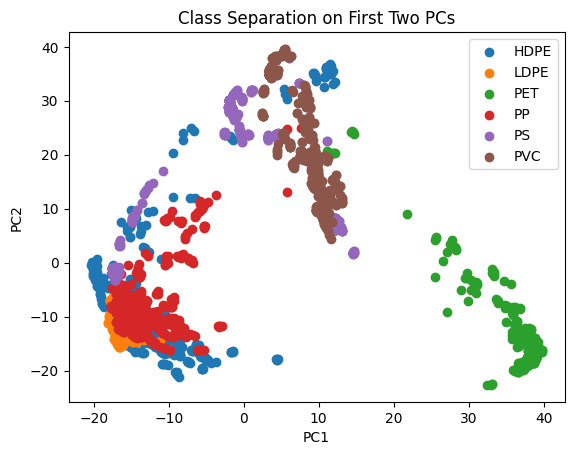

In [56]:
# Standard Normal Variate (SNV) normalization
def snv_transform(matrix):
    """
    Apply Standard Normal Variate (SNV) to each spectrum (row).
    Centers to zero mean and scales to unit std per spectrum.
    """
    mean = np.mean(matrix, axis=1, keepdims=True)
    std = np.std(matrix, axis=1, keepdims=True)
    return (matrix - mean) / std

X_norm = snv_transform(X_sg)

# Dimensionality Reduction with PCA
desired_variance = 0.95  # retain 95% of variance
pca = PCA(n_components=desired_variance, svd_solver='full')
X_pca = pca.fit_transform(X_norm)
print(f"Original feature count: {X_norm.shape[1]}")
print(f"Reduced feature count: {X_pca.shape[1]}")
print(f"X_pca shape: {X_pca.shape}")
print(f"y shape: {y.shape}")

plt.figure()
for cls in np.unique(y):
    idx = np.where(y == cls)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=cls)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Class Separation on First Two PCs')
plt.legend()
plt.show()

# trying Linear SVM / RandomForest

Split into train and test for linear SVM/Random Forest

Linear SVM best params: {'C': 1}
Linear SVM train score: 1.000, CV score: 1.000
Random Forest best params: {'max_depth': 10, 'n_estimators': 50}
Random Forest train score: 1.000, CV score: 0.998


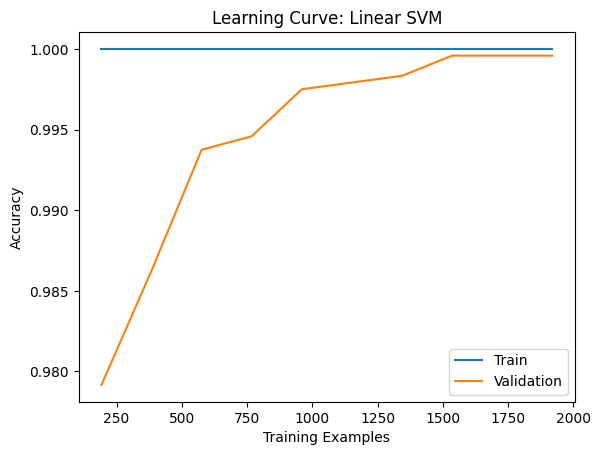

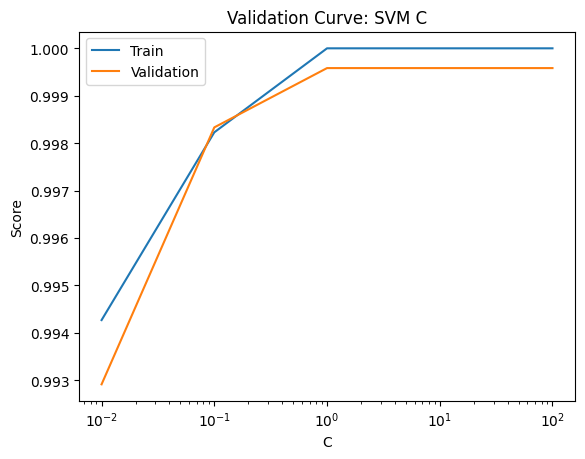

In [60]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, stratify=y, random_state=42)

# Model pipeline & grid search
models = {
    'Linear SVM': SVC(kernel='linear', probability=False),
    'Random Forest': RandomForestClassifier(random_state=42)
}
params = {
    'Linear SVM': {'C': [0.1, 1, 10]},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [None, 10]}
}
best_estimators = {}
for name in models:
    grid = GridSearchCV(models[name], params[name], cv=5, n_jobs=-1, return_train_score=True)
    grid.fit(X_train, y_train)
    best_estimators[name] = grid.best_estimator_
    print(f"{name} best params: {grid.best_params_}")
    # Overfitting check: train vs validation
    train_mean = grid.cv_results_['mean_train_score'][grid.best_index_]
    val_mean = grid.cv_results_['mean_test_score'][grid.best_index_]
    print(f"{name} train score: {train_mean:.3f}, CV score: {val_mean:.3f}")

# Learning curve for Linear SVM
est = best_estimators['Linear SVM']
train_sizes, train_scores, val_scores = learning_curve(
    est, X_train, y_train, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1,1.0,10)
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
plt.figure()
plt.plot(train_sizes, train_mean, label='Train')
plt.plot(train_sizes, val_mean, label='Validation')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve: Linear SVM')
plt.legend()
plt.show()

# Validation curve for SVM C parameter
param_range = [0.01, 0.1, 1, 10, 100]
train_scores_v, val_scores_v = validation_curve(
    SVC(kernel='linear'), X_train, y_train, param_name='C', param_range=param_range, cv=5, n_jobs=-1
)
train_mean_v = train_scores_v.mean(axis=1)
val_mean_v = val_scores_v.mean(axis=1)
plt.figure()
plt.plot(param_range, train_mean_v)
plt.plot(param_range, val_mean_v)
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Score')
plt.title('Validation Curve: SVM C')
plt.legend(['Train', 'Validation'])
plt.show()


Linear SVM Test Report
              precision    recall  f1-score   support

        HDPE       1.00      1.00      1.00       100
        LDPE       1.00      1.00      1.00       100
         PET       1.00      1.00      1.00       100
          PP       1.00      1.00      1.00       100
          PS       1.00      1.00      1.00       100
         PVC       1.00      1.00      1.00       100

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



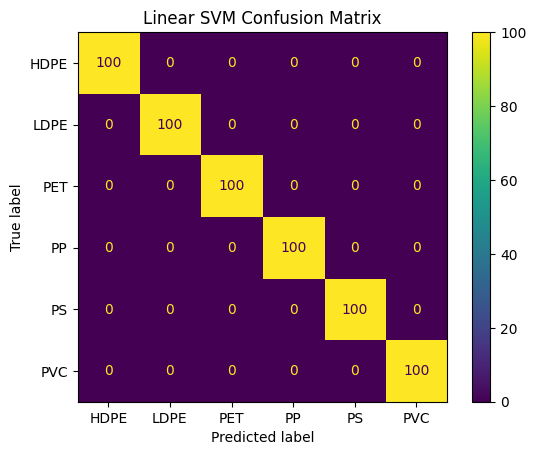


Random Forest Test Report
              precision    recall  f1-score   support

        HDPE       1.00      1.00      1.00       100
        LDPE       1.00      1.00      1.00       100
         PET       1.00      1.00      1.00       100
          PP       1.00      1.00      1.00       100
          PS       1.00      1.00      1.00       100
         PVC       1.00      1.00      1.00       100

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



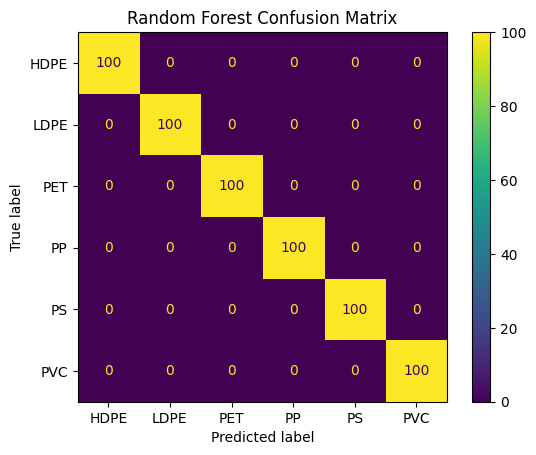

In [61]:
# Final evaluation on test set
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    print(f"\n{name} Test Report")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
    fig, ax = plt.subplots()
    disp.plot(ax=ax)
    plt.title(f"{name} Confusion Matrix")
    plt.show()